In [1]:
# Baseline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import set_config
set_config(display = 'diagram')

# Sklearn preprocessing
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler

# Sklearn pipelines
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline

# Sklearn model selection
from scipy import stats
from sklearn.metrics import make_scorer, mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate

In [2]:
# models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load Dataset

In [3]:
df = pd.read_csv('../data/ml/ml_campaign_raw.csv')
df.head()

,CAMPAIGN_ID,CAMPAIGN_NAME,CAMPAIGN_TYPE,PRODUCT_CATEGORY,TARGET_AUDIENCE,START_DATE,END_DATE,REGION,BUDGET,REACH,...,PCT_MARIES,PCT_CELIBATAIRES,NB_VENTES_REGION_MOIS,CA_REGION_MOIS,PANIER_MOYEN_REGION_MOIS,NB_PROMOS_REGION_MOIS,DISCOUNT_MOYEN_REGION_MOIS,NB_AUTRES_CAMPAGNES_MOIS,BUDGET_TOTAL_REGION_MOIS,REACH_TOTAL_REGION_MOIS
0,CAMP23170,"Howard, Ochoa and Myers",Influencer,Clothing,Families,2013-02-27,2013-03-01,North America,171655.70,613432,...,25.6,25.1,2.0,7777.66,3888.83,0.0,0.0,3.0,845275.10,1414584.0
1,CAMP60979,Chen and Sons,Social Media,Beverages,Young Adults,2010-11-17,2010-12-01,South America,394675.12,931148,...,25.5,29.8,2.0,7968.70,3984.35,0.0,0.0,3.0,1031787.58,1657450.0
2,CAMP15002,Nash LLC,Print,Snacks,Seniors,2016-07-17,2016-07-19,Europe,327128.39,874739,...,25.7,23.5,1.0,2043.62,2043.62,0.0,0.0,7.0,2228370.87,4867794.0
3,CAMP31768,Cruz LLC,Radio,Personal Care,Families,2013-08-07,2013-08-14,North America,361672.16,934057,...,25.6,25.1,1.0,2145.85,2145.85,0.0,0.0,12.0,3687317.18,6896258.0
4,CAMP48275,Cook and Sons,Print,Personal Care,Professionals,2015-05-10,2015-05-11,South America,96731.29,369953,...,25.5,29.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4861 entries, 0 to 4860
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CAMPAIGN_ID                 4861 non-null   object 
 1   CAMPAIGN_NAME               4861 non-null   object 
 2   CAMPAIGN_TYPE               4861 non-null   object 
 3   PRODUCT_CATEGORY            4861 non-null   object 
 4   TARGET_AUDIENCE             4861 non-null   object 
 5   START_DATE                  4861 non-null   object 
 6   END_DATE                    4861 non-null   object 
 7   REGION                      4861 non-null   object 
 8   BUDGET                      4861 non-null   float64
 9   REACH                       4861 non-null   int64  
 10  CONVERSION_RATE             4861 non-null   float64
 11  ANNEE                       4861 non-null   int64  
 12  MOIS                        4861 non-null   int64  
 13  TRIMESTRE                   4861 

In [5]:
df.describe()

,BUDGET,REACH,CONVERSION_RATE,ANNEE,MOIS,TRIMESTRE,JOUR_SEMAINE,DUREE_CAMPAGNE_JOURS,BUDGET_PER_REACH,NB_CLIENTS_REGION,...,PCT_MARIES,PCT_CELIBATAIRES,NB_VENTES_REGION_MOIS,CA_REGION_MOIS,PANIER_MOYEN_REGION_MOIS,NB_PROMOS_REGION_MOIS,DISCOUNT_MOYEN_REGION_MOIS,NB_AUTRES_CAMPAGNES_MOIS,BUDGET_TOTAL_REGION_MOIS,REACH_TOTAL_REGION_MOIS
count,4861.000000,4861.000000,4861.000000,4861.000000,4861.00000,4861.000000,4861.000000,4861.000000,4861.000000,4861.000000,...,4861.000000,4861.000000,2642.000000,2642.000000,2642.000000,2642.0,2642.0,2642.000000,2.642000e+03,2.642000e+03
mean,254166.929368,502059.534869,0.055040,2013.530549,6.54639,2.513269,2.971816,7.447439,1.745659,714.221354,...,26.790105,25.009278,1.482589,7218.939243,4825.728327,0.0,0.0,8.102952,2.061149e+06,4.090766e+06
std,142960.765768,288687.145265,0.025839,2.280924,3.42674,1.114107,1.999441,4.019854,7.687381,17.406989,...,1.401351,2.060155,0.758069,5164.815478,2557.527299,0.0,0.0,2.617623,7.535314e+05,1.463495e+06
min,5000.690000,1610.000000,0.010000,2010.000000,1.00000,1.000000,0.000000,1.000000,0.006053,683.000000,...,25.500000,23.300000,1.000000,12.200000,12.200000,0.0,0.0,1.000000,8.733653e+04,1.946510e+05
25%,128140.480000,253810.000000,0.032900,2012.000000,4.00000,2.000000,1.000000,4.000000,0.259278,703.000000,...,25.600000,23.500000,1.000000,3403.140000,2886.600000,0.0,0.0,6.000000,1.506452e+06,3.057555e+06
50%,257022.600000,502327.000000,0.055500,2014.000000,7.00000,3.000000,3.000000,7.000000,0.505947,713.000000,...,26.300000,24.400000,1.000000,6471.730000,4850.820000,0.0,0.0,8.000000,2.016650e+06,4.095604e+06
75%,376558.660000,755360.000000,0.077300,2015.000000,10.00000,4.000000,5.000000,11.000000,0.999799,726.000000,...,27.900000,25.100000,2.000000,9473.260000,6850.390000,0.0,0.0,10.000000,2.607965e+06,5.220015e+06
max,499976.280000,999919.000000,0.100000,2017.000000,12.00000,4.000000,6.000000,14.000000,219.907890,741.000000,...,29.600000,29.800000,5.000000,29401.180000,9979.520000,0.0,0.0,16.000000,4.270795e+06,7.069939e+06


# Features Engineering

In [6]:
def features_engineering(df):
    df = df.copy()

    # Efficacité de la campagne
    df['CPM'] = df['BUDGET'] / df['REACH']
    df['BUDGET_PER_DAY'] = df['BUDGET'] / df['DUREE_CAMPAGNE_JOURS']
    df['REACH_PER_DAY'] = df['REACH'] / df['DUREE_CAMPAGNE_JOURS']
    
    # Budget ramené au client
    df['BUDGET_PER_CLIENT'] = df['BUDGET'] / df['NB_CLIENTS_REGION']

    # Saisonnalité
    df['IS_Q4'] = (df['TRIMESTRE'] == 4).astype(int)

    return df

In [7]:
df = features_engineering(df)

# X et y

In [8]:
X = df.drop(columns=['CONVERSION_RATE'])
y = df['CONVERSION_RATE']

# Preprocessing

In [9]:
X.isnull().sum().sort_values(ascending=False)

DISCOUNT_MOYEN_REGION_MOIS    2219
PANIER_MOYEN_REGION_MOIS      2219
NB_VENTES_REGION_MOIS         2219
REACH_TOTAL_REGION_MOIS       2219
BUDGET_TOTAL_REGION_MOIS      2219
NB_AUTRES_CAMPAGNES_MOIS      2219
CA_REGION_MOIS                2219
NB_PROMOS_REGION_MOIS         2219
PCT_HOMMES                       0
PCT_MARIES                       0
PCT_CELIBATAIRES                 0
CAMPAIGN_ID                      0
CAMPAIGN_NAME                    0
CPM                              0
BUDGET_PER_DAY                   0
REACH_PER_DAY                    0
BUDGET_PER_CLIENT                0
PCT_FEMMES                       0
REVENU_MOYEN_REGION              0
NB_CLIENTS_REGION                0
BUDGET                           0
CAMPAIGN_TYPE                    0
PRODUCT_CATEGORY                 0
TARGET_AUDIENCE                  0
START_DATE                       0
END_DATE                         0
REGION                           0
REACH                            0
BUDGET_PER_REACH    

In [10]:
list_cols =['REACH_TOTAL_REGION_MOIS',
   'NB_PROMOS_REGION_MOIS', 
   'CA_REGION_MOIS', 
   'PANIER_MOYEN_REGION_MOIS', 
   'NB_VENTES_REGION_MOIS', 
   'DISCOUNT_MOYEN_REGION_MOIS', 
   'NB_AUTRES_CAMPAGNES_MOIS', 
   'BUDGET_TOTAL_REGION_MOIS'] 

X[list_cols]= X[list_cols].fillna(0)
X.isnull().sum().sort_values(ascending=False)

CAMPAIGN_ID                   0
CAMPAIGN_NAME                 0
PCT_HOMMES                    0
PCT_MARIES                    0
PCT_CELIBATAIRES              0
NB_VENTES_REGION_MOIS         0
CA_REGION_MOIS                0
PANIER_MOYEN_REGION_MOIS      0
NB_PROMOS_REGION_MOIS         0
DISCOUNT_MOYEN_REGION_MOIS    0
NB_AUTRES_CAMPAGNES_MOIS      0
BUDGET_TOTAL_REGION_MOIS      0
REACH_TOTAL_REGION_MOIS       0
CPM                           0
BUDGET_PER_DAY                0
REACH_PER_DAY                 0
BUDGET_PER_CLIENT             0
PCT_FEMMES                    0
REVENU_MOYEN_REGION           0
NB_CLIENTS_REGION             0
BUDGET                        0
CAMPAIGN_TYPE                 0
PRODUCT_CATEGORY              0
TARGET_AUDIENCE               0
START_DATE                    0
END_DATE                      0
REGION                        0
REACH                         0
BUDGET_PER_REACH              0
ANNEE                         0
MOIS                          0
TRIMESTR

# Scaling

## Traitement des valeurs numériques

Connaissant déjà le dataset suite aux premières recherches pendant la création du modèle prédictif, nous nous concentrons sur les nouvelles features créées.

In [11]:
num_cols = X.select_dtypes(exclude='object').columns

In [12]:
num_cols

Index(['BUDGET', 'REACH', 'ANNEE', 'MOIS', 'TRIMESTRE', 'JOUR_SEMAINE',
       'DUREE_CAMPAGNE_JOURS', 'BUDGET_PER_REACH', 'NB_CLIENTS_REGION',
       'REVENU_MOYEN_REGION', 'PCT_FEMMES', 'PCT_HOMMES', 'PCT_MARIES',
       'PCT_CELIBATAIRES', 'NB_VENTES_REGION_MOIS', 'CA_REGION_MOIS',
       'PANIER_MOYEN_REGION_MOIS', 'NB_PROMOS_REGION_MOIS',
       'DISCOUNT_MOYEN_REGION_MOIS', 'NB_AUTRES_CAMPAGNES_MOIS',
       'BUDGET_TOTAL_REGION_MOIS', 'REACH_TOTAL_REGION_MOIS', 'CPM',
       'BUDGET_PER_DAY', 'REACH_PER_DAY', 'BUDGET_PER_CLIENT', 'IS_Q4'],
      dtype='object')

In [13]:
feat_eng_cols = ['CPM', 'BUDGET_PER_DAY', 'REACH_PER_DAY', 'BUDGET_PER_CLIENT', 'IS_Q4']

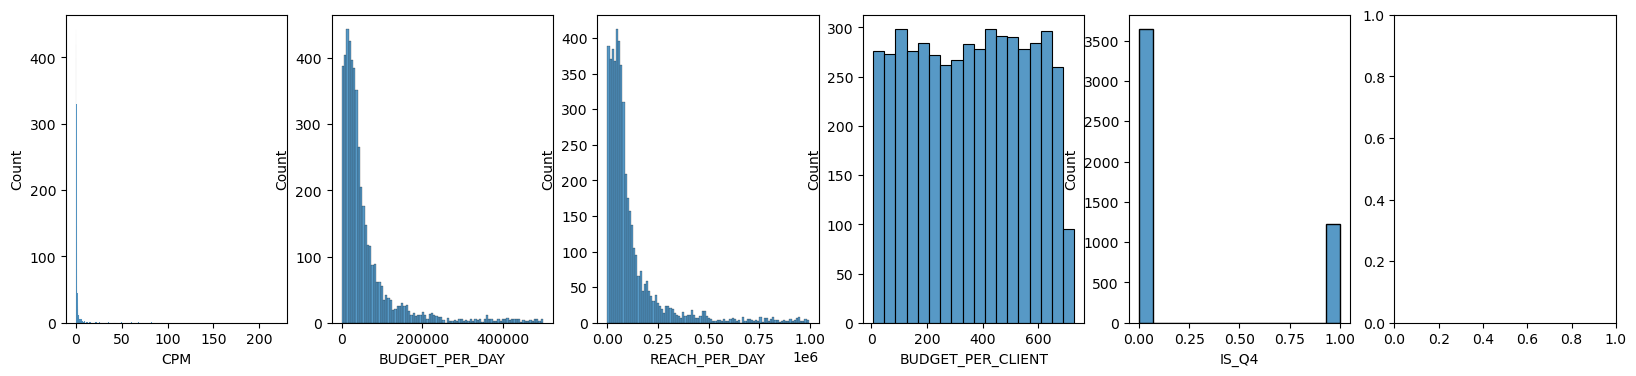

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20, 4))

for col, ax in zip(feat_eng_cols, axes.ravel()):
    sns.histplot(X[col], ax=ax)

In [15]:
num_cols

Index(['BUDGET', 'REACH', 'ANNEE', 'MOIS', 'TRIMESTRE', 'JOUR_SEMAINE',
       'DUREE_CAMPAGNE_JOURS', 'BUDGET_PER_REACH', 'NB_CLIENTS_REGION',
       'REVENU_MOYEN_REGION', 'PCT_FEMMES', 'PCT_HOMMES', 'PCT_MARIES',
       'PCT_CELIBATAIRES', 'NB_VENTES_REGION_MOIS', 'CA_REGION_MOIS',
       'PANIER_MOYEN_REGION_MOIS', 'NB_PROMOS_REGION_MOIS',
       'DISCOUNT_MOYEN_REGION_MOIS', 'NB_AUTRES_CAMPAGNES_MOIS',
       'BUDGET_TOTAL_REGION_MOIS', 'REACH_TOTAL_REGION_MOIS', 'CPM',
       'BUDGET_PER_DAY', 'REACH_PER_DAY', 'BUDGET_PER_CLIENT', 'IS_Q4'],
      dtype='object')

In [16]:
robust_feat =['BUDGET_PER_REACH', 'PCT_MARIES', 'PCT_CELIBATAIRES', 'NB_VENTES_REGION_MOIS', 'CA_REGION_MOIS', 'PANIER_MOYEN_REGION_MOIS', 'NB_AUTRES_CAMPAGNES_MOIS', 'REACH_TOTAL_REGION_MOIS', 'BUDGET_TOTAL_REGION_MOIS', 'BUDGET_PER_CLIENT']
standard_feat =['BUDGET','REACH', 'DUREE_CAMPAGNE_JOURS', 'NB_CLIENTS_REGION', 'REVENU_MOYEN_REGION', 'PCT_FEMMES', 'PCT_HOMMES', 'NB_PROMOS_REGION_MOIS', 'DISCOUNT_MOYEN_REGION_MOIS', 'CPM', 'BUDGET_PER_DAY', 'REACH_PER_DAY']
not_to_scale = ['ANNEE', 'MOIS', 'TRIMESTRE', 'JOUR_SEMAINE', 'IS_Q4']

In [17]:
len(robust_feat) + len(standard_feat) + len(not_to_scale)

27

In [18]:
len(num_cols)

27

In [19]:
preproc_num = make_column_transformer(
    (StandardScaler(), standard_feat),
    (RobustScaler(), robust_feat),
    ('passthrough', not_to_scale),
    remainder='drop'
)
preproc_num

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['BUDGET', 'REACH', 'DUREE_CAMPAGNE_JOURS',
                                  'NB_CLIENTS_REGION', 'REVENU_MOYEN_REGION',
                                  'PCT_FEMMES', 'PCT_HOMMES',
                                  'NB_PROMOS_REGION_MOIS',
                                  'DISCOUNT_MOYEN_REGION_MOIS', 'CPM',
                                  'BUDGET_PER_DAY', 'REACH_PER_DAY']),
                                ('robustscaler', RobustScaler(),
                                 ['BUDGET_PER_REACH', 'PCT_MARIES',
                                  'PCT_CELIBATAIRES', 'NB_VENTES_REGION_MOIS',
                                  'CA_REGION_MOIS', 'PANIER_MOYEN_REGION_MOIS',
                                  'NB_AUTRES_CAMPAGNES_MOIS',
                                  'REACH_TOTAL_REGION_MOIS',
                                  'BUDGET_TOTAL_REGION_MOIS',
                                  'BUDGET_PER_CLIENT']),
                                ('passthrough', 'passthrough',
                                 ['ANNEE', 'MOIS', 'TRIMESTRE', 'JOUR_SEMAINE',
                                  'IS_Q4'])])

# Traiter les valeurs catégoriques

In [20]:
X.select_dtypes(include='object').columns

Index(['CAMPAIGN_ID', 'CAMPAIGN_NAME', 'CAMPAIGN_TYPE', 'PRODUCT_CATEGORY',
       'TARGET_AUDIENCE', 'START_DATE', 'END_DATE', 'REGION', 'MOIS_DEBUT'],
      dtype='object')

In [21]:
cat_cols = ['CAMPAIGN_TYPE', 'PRODUCT_CATEGORY', 'TARGET_AUDIENCE', 'REGION']

In [22]:
preproc_cat = make_pipeline(
    (OneHotEncoder(handle_unknown='ignore')),
    (StandardScaler(with_mean=False))
    )
preproc_cat

Pipeline(steps=[('onehotencoder', OneHotEncoder(handle_unknown='ignore')),
                ('standardscaler', StandardScaler(with_mean=False))])

# Pipeline complet

In [23]:
preproc = make_column_transformer(
            (preproc_num, num_cols),
            (preproc_cat, cat_cols),
            remainder='drop'                
            )
preproc


ColumnTransformer(transformers=[('columntransformer',
                                 ColumnTransformer(transformers=[('standardscaler',
                                                                  StandardScaler(),
                                                                  ['BUDGET',
                                                                   'REACH',
                                                                   'DUREE_CAMPAGNE_JOURS',
                                                                   'NB_CLIENTS_REGION',
                                                                   'REVENU_MOYEN_REGION',
                                                                   'PCT_FEMMES',
                                                                   'PCT_HOMMES',
                                                                   'NB_PROMOS_REGION_MOIS',
                                                                   'DISCOUNT_MOYEN_REGION_MOIS',
                                                                   'CPM',
                                                                   'BUDGET_PER_DAY',
                                                                   'REACH_PER_DAY']),
                                                                 ('robustscaler',
                                                                  RobustScale...
       'DISCOUNT_MOYEN_REGION_MOIS', 'NB_AUTRES_CAMPAGNES_MOIS',
       'BUDGET_TOTAL_REGION_MOIS', 'REACH_TOTAL_REGION_MOIS', 'CPM',
       'BUDGET_PER_DAY', 'REACH_PER_DAY', 'BUDGET_PER_CLIENT', 'IS_Q4'],
      dtype='object')),
                                ('pipeline',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore')),
                                                 ('standardscaler',
                                                  StandardScaler(with_mean=False))]),
                                 ['CAMPAIGN_TYPE', 'PRODUCT_CATEGORY',
                                  'TARGET_AUDIENCE', 'REGION'])])

In [24]:
preproc.fit_transform(X).shape, preproc.fit_transform(X)

((4861, 53),
 array([[-0.57721933,  0.38582917, -1.35527307, ...,  2.87936849,
          0.        ,  0.        ],
        [ 0.98294553,  1.48649711,  1.63021743, ...,  0.        ,
          0.        ,  2.83317781],
        [ 0.51041253,  1.29107863, -1.35527307, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-1.15013523, -1.20865938,  0.38626306, ...,  0.        ,
          2.83152291,  0.        ],
        [ 1.06503537,  1.57830836, -0.11131869, ...,  0.        ,
          2.83152291,  0.        ],
        [-0.23793177, -1.43824985,  0.38626306, ...,  2.87936849,
          0.        ,  0.        ]]))

In [25]:
X_scaled = preproc.fit_transform(X)

In [26]:
np.isnan(X_scaled).sum()

0

# Determiner le nombre optimal de clusters

## Elbow Method (vue au Wagon)

In [27]:
!pip install threadpoolctl==3.1.0

In [28]:
KMeans(n_clusters=2, random_state=42).fit(X_scaled).inertia_

c:\Users\Lucas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


476574.83853557875

In [29]:
wcss = []
clusters = list(range(1, 11))

for k in clusters:
    km_test = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    wcss.append(km_test.inertia_)

c:\Users\Lucas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Lucas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Lucas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Lucas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Lucas\anaconda3\Lib\site-packages\sklearn\clust

Text(0.5, 0, 'k cluster number')

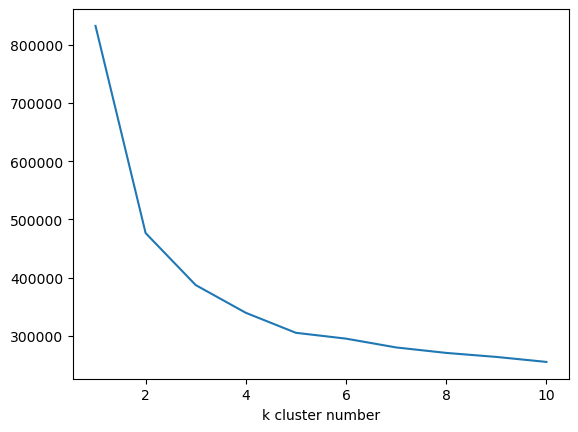

In [30]:
plt.plot(clusters, wcss)
plt.xlabel('k cluster number')

Suite à l'analyse de la courbe, le nombre de clusters optimal semble être 5

# Clustering

In [31]:
model = KMeans(n_clusters=5, random_state=42)
model.fit(X_scaled)
y_pred = model.predict(X_scaled)

c:\Users\Lucas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## Analyse avec PCA

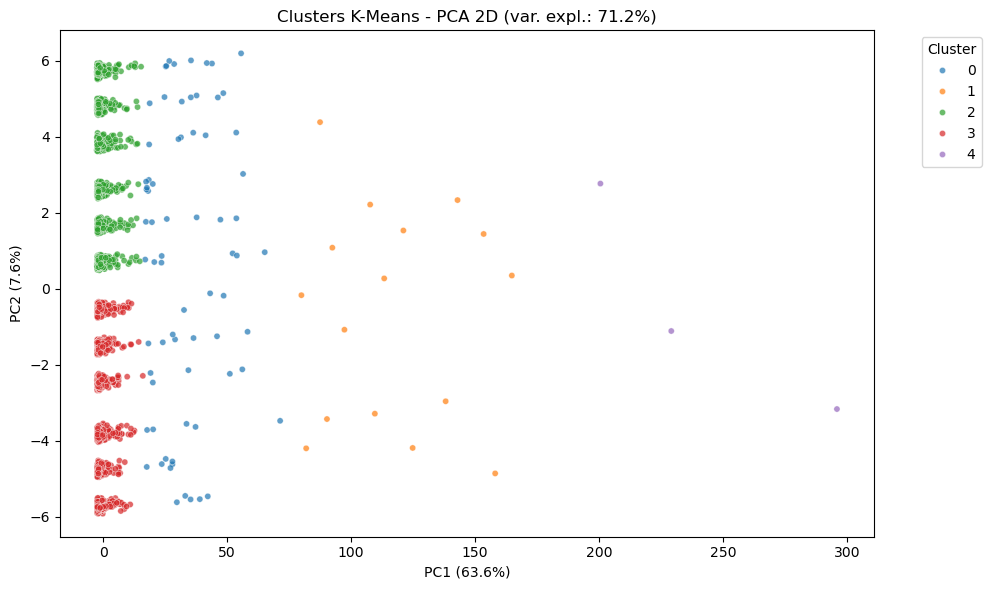

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_pred,
    palette='tab10',
    s=20,
    alpha=0.7,
)
plt.title(f'Clusters K-Means - PCA 2D (var. expl.: {pca.explained_variance_ratio_.sum():.1%})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:
X_clustered = X.copy()
X_clustered['cluster'] = y_pred

X_clustered.groupby('cluster')[[
    'BUDGET', 'REACH',
    'BUDGET_PER_REACH', 'BUDGET_PER_CLIENT'
]].mean().round(2)

,BUDGET,REACH,BUDGET_PER_REACH,BUDGET_PER_CLIENT
cluster,,,,
0,328410.78,13962.49,26.45,460.63
1,343694.94,4097.62,87.59,485.76
2,252587.41,512821.42,0.99,354.06
3,252724.70,510039.38,0.96,353.87
4,395659.66,2190.67,180.05,572.64


# Insights Business

Nous avons identifié 5 clusters, analysons ce qu'ils représentent d'un point de vue business

In [34]:
X_analysis = X.copy()
X_analysis['CONVERSION_RATE'] = y.values
X_analysis['cluster'] = y_pred

print(f"Nombre de campagnes : {X_analysis.shape[0]}, nombre de colonnes : {X_analysis.shape[1]}")

Nombre de campagnes : 4861, nombre de colonnes : 38


In [35]:
profils = X_analysis.groupby('cluster').agg({
    'BUDGET': 'mean',
    'REACH': 'mean',
    'CONVERSION_RATE': 'mean',
    'BUDGET_PER_REACH': 'mean',
    'BUDGET_PER_CLIENT': 'mean',
    'DUREE_CAMPAGNE_JOURS': 'mean'
}).round(2)

In [36]:
profils['N_CAMPAGNES'] = X_analysis.groupby('cluster').size()

profils

,BUDGET,REACH,CONVERSION_RATE,BUDGET_PER_REACH,BUDGET_PER_CLIENT,DUREE_CAMPAGNE_JOURS,N_CAMPAGNES
cluster,,,,,,,
0,328410.78,13962.49,0.06,26.45,460.63,7.85,72
1,343694.94,4097.62,0.06,87.59,485.76,7.06,16
2,252587.41,512821.42,0.06,0.99,354.06,7.47,2353
3,252724.70,510039.38,0.05,0.96,353.87,7.42,2417
4,395659.66,2190.67,0.03,180.05,572.64,4.33,3


In [37]:
for cluster in range(5):
    cluster_data = X_analysis[X_analysis['cluster'] == cluster]
    
    print(f"\n{'─'*100}")
    print(f"CLUSTER {cluster} - {len(cluster_data)} campagnes")
    print(f"{'─'*100}")
    
    # Métriques clés
    budget_mean = cluster_data['BUDGET'].mean()
    reach_mean = cluster_data['REACH'].mean()
    cr_mean = cluster_data['CONVERSION_RATE'].mean()
    cost_per_reach = cluster_data['BUDGET_PER_REACH'].mean()
    
    print(f"Budget moyen         : {budget_mean} €")
    print(f"Reach moyen          : {reach_mean} personnes")
    print(f"Conversion Rate moy. : {cr_mean}")
    print(f"Coût par contact     : {cost_per_reach} €")
    
    # Typologie
    print(f"\n TYPOLOGIE :")
    if reach_mean > 400000:
        print("- CAMPAGNES MASS MARKET")
        print("- Grande audience, faible coût unitaire")
        print("- Stratégie : Maximiser la visibilité")
    elif reach_mean < 50000:
        print("- CAMPAGNES PREMIUM ULTRA-CIBLÉES")
        print("- Petite audience, coût élevé par contact")
        print("- Stratégie : Haute valeur, public exclusif")
    else:
        print("- CAMPAGNES CIBLÉES ÉQUILIBRÉES")
        print("- Audience moyenne, coût modéré")
        print("- Stratégie : Balance qualité/quantité")
    
    # Types de campagnes et régions dominantes
    top_types = cluster_data['CAMPAIGN_TYPE'].value_counts().head(2)
    print(f"\n Types dominants : {', '.join(top_types.index.tolist())}")
    
    top_regions = cluster_data['REGION'].value_counts().head(2)
    print(f" Régions principales : {', '.join(top_regions.index.tolist())}")



────────────────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 0 - 72 campagnes
────────────────────────────────────────────────────────────────────────────────────────────────────
Budget moyen         : 328410.78041666665 €
Reach moyen          : 13962.486111111111 personnes
Conversion Rate moy. : 0.057249999999999995
Coût par contact     : 26.450661138194445 €

 TYPOLOGIE :
- CAMPAGNES PREMIUM ULTRA-CIBLÉES
- Petite audience, coût élevé par contact
- Stratégie : Haute valeur, public exclusif

 Types dominants : Influencer, TV
 Régions principales : Asia, Africa

────────────────────────────────────────────────────────────────────────────────────────────────────
CLUSTER 1 - 16 campagnes
────────────────────────────────────────────────────────────────────────────────────────────────────
Budget moyen         : 343694.93937499996 €
Reach moyen          : 4097.625 personnes
Conversion Rate moy. : 0.058625000000000003
Coût par contact     : 87

C:\Users\Lucas\AppData\Local\Temp\ipykernel_48504\3763339152.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_analysis, x='cluster', y='CONVERSION_RATE',


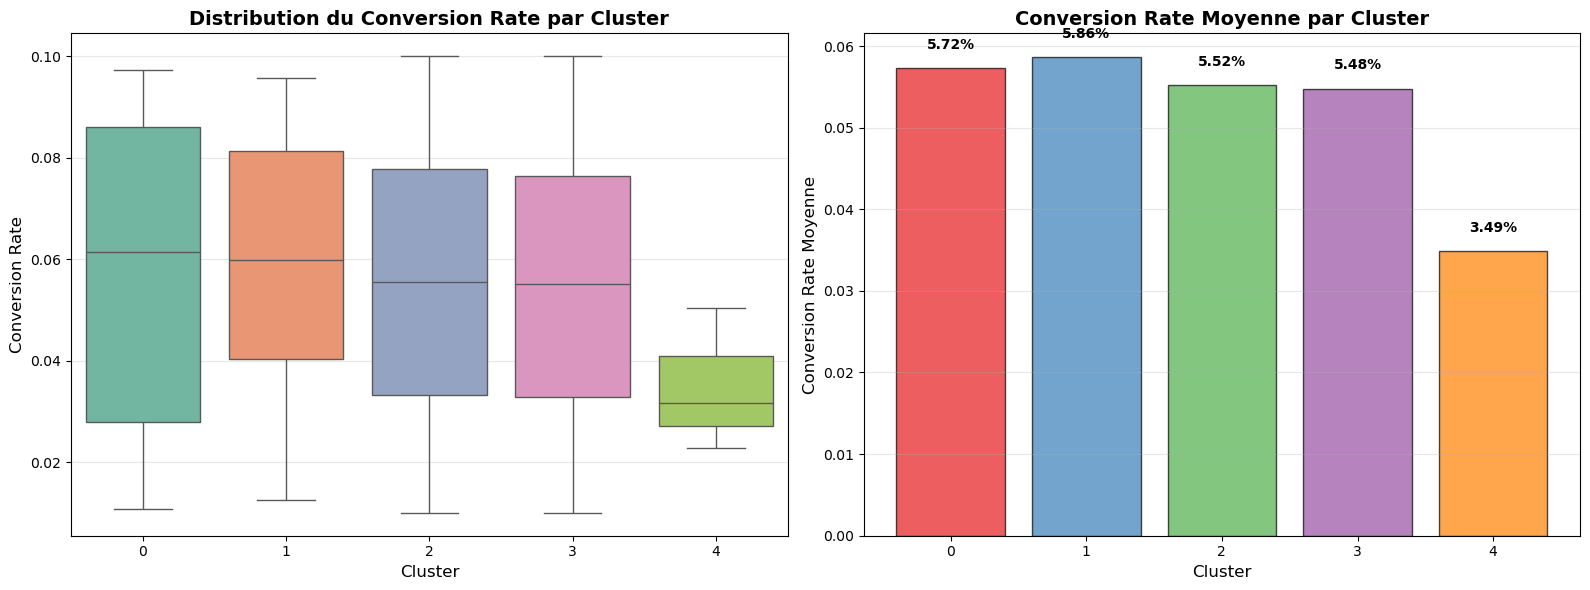

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1 : Boxplot
sns.boxplot(data=X_analysis, x='cluster', y='CONVERSION_RATE', 
            palette='Set2', ax=axes[0])
axes[0].set_title('Distribution du Conversion Rate par Cluster', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Conversion Rate', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2 : Barplot moyennes
cluster_means = X_analysis.groupby('cluster')['CONVERSION_RATE'].mean()
colors_bar = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
axes[1].bar(range(5), cluster_means, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].set_title('Conversion Rate Moyenne par Cluster', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Conversion Rate Moyenne', fontsize=12)
axes[1].set_xticks(range(5))
axes[1].grid(axis='y', alpha=0.3)


for i, v in enumerate(cluster_means):
    axes[1].text(i, v + 0.002, f'{v:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

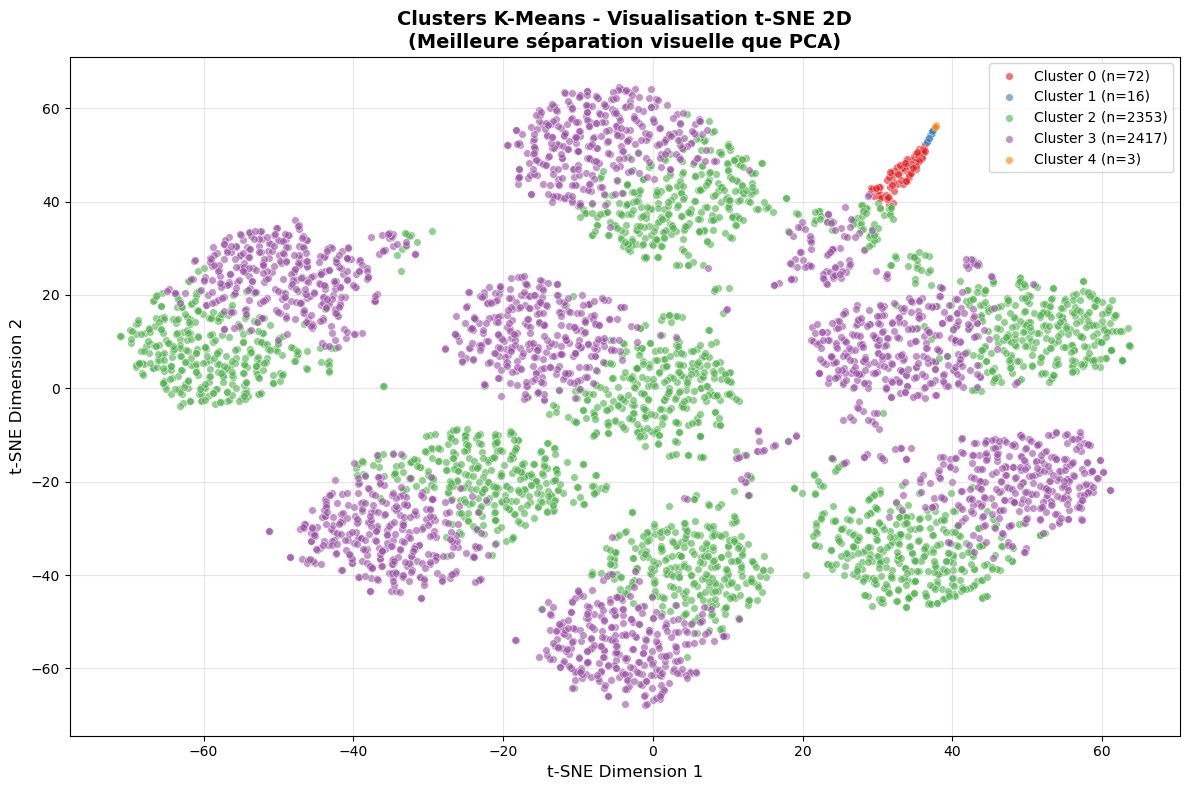

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors_tsne = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

for cluster in range(5):
    mask = y_pred == cluster
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors_tsne[cluster], 
                label=f'Cluster {cluster} (n={mask.sum()})',
                alpha=0.6, s=30, edgecolors='white', linewidth=0.5)

plt.title('Clusters K-Means - Visualisation t-SNE 2D\n(Meilleure séparation visuelle que PCA)', 
          fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion et analyses

## 5 types de campagnes identifiés

Le clustering nous a permis d'identifier 5 profils différents de campagnes marketing.

In [40]:
for cluster in [0, 2, 3]:
    data = X_analysis[X_analysis['cluster'] == cluster]
    
    print(f"\n--- Cluster {cluster} - {len(data)} campagnes ---")
    
    # Métriques de base
    print(f"Budget moyen : {data['BUDGET'].mean():,.0f} €")
    print(f"Reach moyen : {data['REACH'].mean():,.0f} personnes")
    print(f"Taux de conversion : {data['CONVERSION_RATE'].mean():.2%}")
    print(f"Coût par contact : {data['BUDGET_PER_REACH'].mean():.2f} €")
    
    # Types de campagnes les plus utilisés
    print(f"\nTypes de campagnes principaux :")
    top_types = data['CAMPAIGN_TYPE'].value_counts().head(3)
    for camp_type, count in top_types.items():
        print(f"  - {camp_type}: {count} campagnes")
    
    # Régions principales
    print(f"Régions principales :")
    top_regions = data['REGION'].value_counts().head(3)
    for region, count in top_regions.items():
        print(f"  - {region}: {count} campagnes")


--- Cluster 0 - 72 campagnes ---
Budget moyen : 328,411 €
Reach moyen : 13,962 personnes
Taux de conversion : 5.72%
Coût par contact : 26.45 €

Types de campagnes principaux :
  - Influencer: 13 campagnes
  - TV: 12 campagnes
  - Radio: 12 campagnes
Régions principales :
  - Asia: 13 campagnes
  - Africa: 11 campagnes
  - Middle East and North Africa: 11 campagnes

--- Cluster 2 - 2353 campagnes ---
Budget moyen : 252,587 €
Reach moyen : 512,821 personnes
Taux de conversion : 5.52%
Coût par contact : 0.99 €

Types de campagnes principaux :
  - Social Media: 361 campagnes
  - Influencer: 349 campagnes
  - Email: 339 campagnes
Régions principales :
  - Middle East and North Africa: 365 campagnes
  - South America: 349 campagnes
  - Asia: 338 campagnes

--- Cluster 3 - 2417 campagnes ---
Budget moyen : 252,725 €
Reach moyen : 510,039 personnes
Taux de conversion : 5.48%
Coût par contact : 0.96 €

Types de campagnes principaux :
  - Print: 351 campagnes
  - Radio: 351 campagnes
  - TV: 34

**3 clusters ressortent du lot :**
- Le cluster 0 est clairement le plus performant avec des campagnes qui ont un meilleur taux de conversion. Le budget moyen et le coût par contact sont en revanche très élevés.
- Les clusters 2 et 3 ressortent car ils représentent la majorité de l'échantillon. Ce sont des campagnes marketing (mass marketing) plus équilibrées avec un budget moyen beaucoup moins élevés mais un taux de conversion plus faible.

In [41]:
cluster4 = X_analysis[X_analysis['cluster'] == 4]
cluster0 = X_analysis[X_analysis['cluster'] == 0]

if len(cluster4) > 0:
    print(f"\nNombre de campagnes : {len(cluster4)}")
    print(f"Budget moyen : {cluster4['BUDGET'].mean():,.0f} €")
    print(f"Conversion : {cluster4['CONVERSION_RATE'].mean():.2%}")
    print(f"Coût par contact : {cluster4['BUDGET_PER_REACH'].mean():.2f} €")

    print(f"Type de campagne : {cluster4['CAMPAIGN_TYPE'].value_counts().idxmax()}")

    print(f"\nComparaison avec Cluster 0 (le meilleur) :")
    print(f"  Conversion : {cluster4['CONVERSION_RATE'].mean():.2%} vs {cluster0['CONVERSION_RATE'].mean():.2%}")
    print(f"  → Cluster 4 est 2x moins performant !")
    print(f"\n  Recommandation : Arrêter ce type de campagne")



Nombre de campagnes : 3
Budget moyen : 395,660 €
Conversion : 3.49%
Coût par contact : 180.05 €
Type de campagne : Radio

Comparaison avec Cluster 0 (le meilleur) :
  Conversion : 3.49% vs 5.72%
  → Cluster 4 est 2x moins performant !

  Recommandation : Arrêter ce type de campagne


Le cluster 4 représente LE type de campagnes marketing **à ne plus réaliser**.
Les campagnes marketing qui composent ce cluster doivent surement être très ciblées car elles sont peu et leur coût moyen est élevé.

In [42]:
# situation et répartition actuelle

total_budget = X_analysis['BUDGET'].sum()
print(f"\nBudget total actuel : {total_budget:,.0f} €")

for cluster in range(5):
    data = X_analysis[X_analysis['cluster'] == cluster]
    pct = len(data) / len(X_analysis) * 100
    budget_cluster = data['BUDGET'].sum()
    pct_budget = budget_cluster / total_budget * 100
    print(f"  Cluster {cluster} : {pct:.1f}% des campagnes, {pct_budget:.1f}% du budget")

# Nouvelle allocation de campagnes recommandée
print(f"\nNouvelle allocation (avec -30% de budget) :")
budget_reduit = total_budget * 0.7
print(f"  Budget disponible : {budget_reduit:,.0f} €")
print(f"\n  70% → Clusters 2-3 (mass market) : {budget_reduit * 0.70:,.0f} €")
print(f"  25% → Cluster 0 (ciblé performant) : {budget_reduit * 0.25:,.0f} €")
print(f"   5% → Cluster 1 (premium) : {budget_reduit * 0.05:,.0f} €")
print(f"   0% → Cluster 4 (à arrêter) : 0 €")

# Impact sur la conversion
conv_actuelle = X_analysis['CONVERSION_RATE'].mean()
conv_cluster0 = cluster0['CONVERSION_RATE'].mean()
conv_cluster23 = X_analysis[X_analysis['cluster'].isin([2,3])]['CONVERSION_RATE'].mean()

conv_projetee = (0.70 * conv_cluster23) + (0.30 * conv_cluster0)

print(f"\nImpact attendu sur la conversion :")
print(f"  Actuelle : {conv_actuelle:.2%}")
print(f"  Projetée : {conv_projetee:.2%}")
print(f"  Gain : +{(conv_projetee - conv_actuelle):.2%}")


Budget total actuel : 1,235,505,444 €
  Cluster 0 : 1.5% des campagnes, 1.9% du budget
  Cluster 1 : 0.3% des campagnes, 0.4% du budget
  Cluster 2 : 48.4% des campagnes, 48.1% du budget
  Cluster 3 : 49.7% des campagnes, 49.4% du budget
  Cluster 4 : 0.1% des campagnes, 0.1% du budget

Nouvelle allocation (avec -30% de budget) :
  Budget disponible : 864,853,811 €

  70% → Clusters 2-3 (mass market) : 605,397,667 €
  25% → Cluster 0 (ciblé performant) : 216,213,453 €
   5% → Cluster 1 (premium) : 43,242,691 €
   0% → Cluster 4 (à arrêter) : 0 €

Impact attendu sur la conversion :
  Actuelle : 5.50%
  Projetée : 5.57%
  Gain : +0.06%


## Projection d'une nouvelle allocation de campagnes

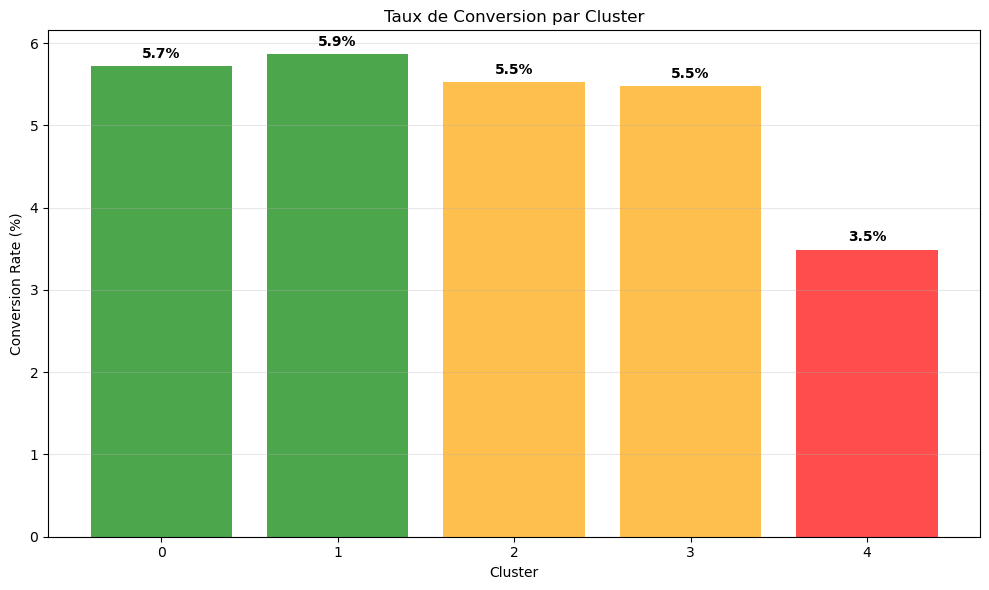

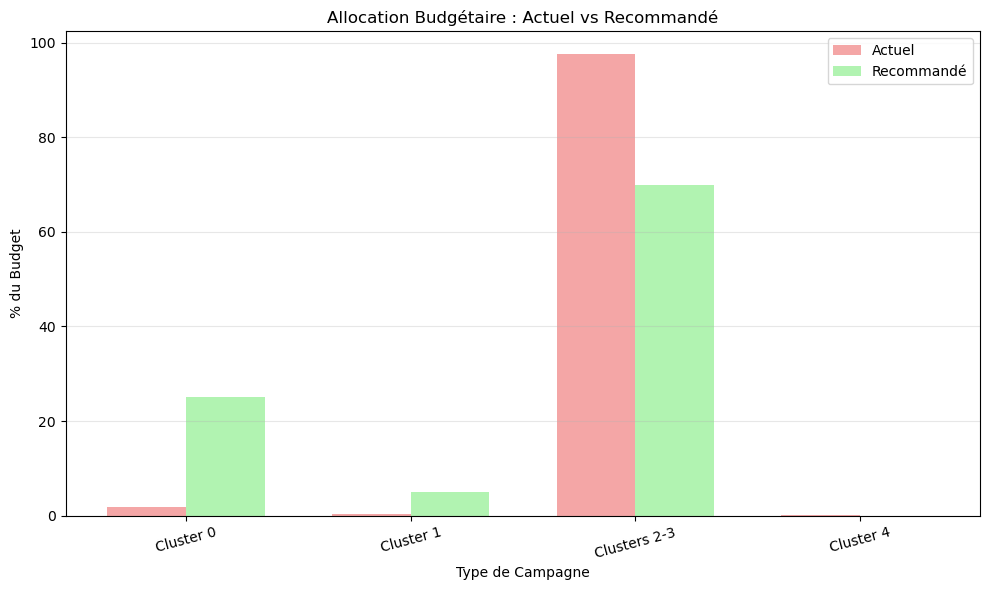

In [43]:
# Graphique 1 : Conversion par cluster
fig, ax = plt.subplots(figsize=(10, 6))

clusters_list = [0, 1, 2, 3, 4]
conversions = []
colors = []

for cluster in clusters_list:
    data = X_analysis[X_analysis['cluster'] == cluster]
    conv = data['CONVERSION_RATE'].mean()
    conversions.append(conv * 100)
    
    # Couleur selon performance
    if cluster in [0, 1]:
        colors.append('green')
    elif cluster in [2, 3]:
        colors.append('orange')
    else:
        colors.append('red')

ax.bar(clusters_list, conversions, color=colors, alpha=0.7)
ax.set_xlabel('Cluster')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Taux de Conversion par Cluster')
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, v in enumerate(conversions):
    ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Graphique 2 : Budget actuel vs recommandé
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Cluster 0', 'Cluster 1', 'Clusters 2-3', 'Cluster 4']

# Calcul allocation actuelle
actuel = [
    X_analysis[X_analysis['cluster'] == 0]['BUDGET'].sum() / total_budget * 100,
    X_analysis[X_analysis['cluster'] == 1]['BUDGET'].sum() / total_budget * 100,
    X_analysis[X_analysis['cluster'].isin([2,3])]['BUDGET'].sum() / total_budget * 100,
    X_analysis[X_analysis['cluster'] == 4]['BUDGET'].sum() / total_budget * 100
]

recommande = [25, 5, 70, 0]

x = range(len(categories))
width = 0.35

ax.bar([i - width/2 for i in x], actuel, width, label='Actuel', color='lightcoral', alpha=0.7)
ax.bar([i + width/2 for i in x], recommande, width, label='Recommandé', color='lightgreen', alpha=0.7)

ax.set_xlabel('Type de Campagne')
ax.set_ylabel('% du Budget')
ax.set_title('Allocation Budgétaire : Actuel vs Recommandé')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusion et recommandations

Selon nos observations, plusieurs points d'actions peuvent être engagés pour augmenter l'efficacité des campagnes marketing

1. MAINTENIR Clusters 2-3 (70% du budget)
- Base solide, bon ROI, portée massive

2. AUGMENTER Cluster 0 (25% du budget)
- Meilleure conversion (~6%)
- Actuellement sous-exploité (1.5% seulement)
- C'est le levier vers des campagnes plus efficaces

3. ARRÊTER Cluster 4 (0% du budget)
- Performance catastrophique (3% conversion)
- Coût beaucoup trop important (180€/contact)

# Extraction des campagnes par cluster

Extraction destinée à de potentielles analyses futures

In [44]:
campagnes_par_cluster = X_analysis[[
    'CAMPAIGN_ID', 
    'CAMPAIGN_NAME',
    'cluster',
    'CAMPAIGN_TYPE',
    'PRODUCT_CATEGORY',
    'REGION',
    'BUDGET',
    'REACH',
    'CONVERSION_RATE',
    'BUDGET_PER_REACH'
]].copy()

# Trier par cluster puis par conversion décroissante
campagnes_par_cluster = campagnes_par_cluster.sort_values(
    by=['cluster', 'CONVERSION_RATE'], 
    ascending=[True, False]
)

In [51]:
campagnes_par_cluster.head()

,CAMPAIGN_ID,CAMPAIGN_NAME,cluster,CAMPAIGN_TYPE,PRODUCT_CATEGORY,REGION,BUDGET,REACH,CONVERSION_RATE,BUDGET_PER_REACH
2789,CAMP70552,"Riley, Donaldson and Klein",0,TV,Baby Food,Africa,490244.41,20326,0.0973,24.119080
4366,CAMP53959,Hines Ltd,0,Content Marketing,Clothing,Asia,230455.74,5847,0.0966,39.414356
3308,CAMP34993,Rodriguez and Sons,0,Influencer,Household,Middle East and North Africa,209304.63,10947,0.0954,19.119816
3008,CAMP16008,Carpenter Inc,0,Radio,Personal Care,South America,303805.90,19180,0.0952,15.839724
3724,CAMP63646,Acosta Inc,0,Print,Personal Care,Africa,437749.94,14834,0.0949,29.509906


# Export du clustering

Nous utilisons notre clustering dans notre page Streamlit dédiée

In [53]:
campagnes_par_cluster.to_csv('../data/ml/campaigns_clustered.csv', index=False)
